In [8]:
import powerlaw
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
from collections import Counter
# import numpy as np
# import seaborn as sns
import xgi
# from matplotlib import cm
# from draw import *
notebook_dir = os.getcwd()  # This gets the current working directory in Jupyter
parent_dir = os.path.abspath(os.path.join(notebook_dir, '..'))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)
from sod import *
from sod.simpliciality import edit_simpliciality
# from sod.simpliciality import edge_rewiring
from edge_rewiring import edge_rewiring_alg
from edge_rewiring import edge_rewiring_exper
from edge_rewiring import power_law

C_distribution: [1 6 4 5]
[0, 2, 3, 4]
[1, 3, 4]
[1, 3]
[1, 2, 3]


(<Axes: >,
 (<matplotlib.collections.PathCollection at 0x1481a8910>,
  <matplotlib.collections.PatchCollection at 0x1481a8550>))

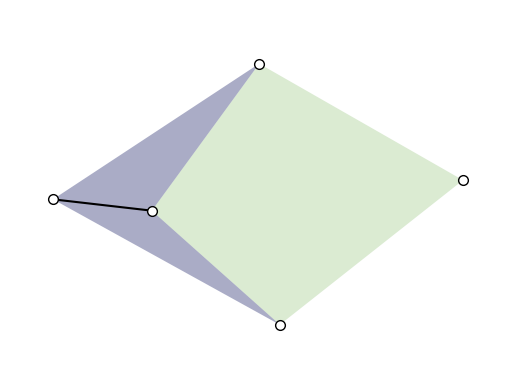

In [428]:
from edge_rewiring import model_generation
import matplotlib.pyplot as plt

# Generate hypergraph
# H = xgi.load_xgi_data(edge_rewiring_exper.datasets[0], max_order=11)
H = model_generation.model_generation_es(es=0.3, approx_num_C=16, num_max_hyperedge=4,num_node=5, min_size=2, max_size=3)
for edge in H.edges.members():
    print(list(edge))

xgi.draw(H)


In [ ]:
H = model_generation.model_generation_sf(sf=0.3, approx_num_E=1000, num_node=1000, min_size=2, max_size=None)
for edge in H.edges.members():
    print(list(edge))

S_total: -124
edge_total: 908
sf_tmp 0.8361445783132531
[944, 260, 303, 767]
[259, 971, 647, 759, 299, 381]
[128, 253]
[737, 253]
[443, 253]
[253, 318]
[253, 822]
[128, 737]
[128, 318]
[128, 822]
[737, 443]
[737, 318]
[737, 822]
[443, 318]
[443, 822]
[822, 318]
[128, 737, 253]
[128, 443, 253]
[128, 253, 318]
[128, 253, 822]
[737, 443, 253]
[737, 253, 318]
[737, 253, 822]
[443, 253, 318]
[443, 253, 822]
[822, 253, 318]
[128, 737, 443]
[128, 737, 318]
[128, 737, 822]
[128, 443, 318]
[128, 443, 822]
[128, 822, 318]
[737, 443, 318]
[737, 443, 822]
[822, 737, 318]
[822, 443, 318]
[128, 737, 443, 253]
[128, 737, 253, 318]
[128, 737, 253, 822]
[128, 443, 253, 318]
[128, 443, 253, 822]
[128, 822, 253, 318]
[737, 443, 253, 318]
[737, 443, 253, 822]
[822, 737, 253, 318]
[128, 737, 443, 318]
[128, 737, 443, 822]
[128, 737, 318, 822]
[128, 822, 443, 318]
[822, 737, 443, 318]
[128, 737, 443, 253, 318]
[128, 737, 822, 443, 253]
[128, 737, 822, 253, 318]
[128, 822, 443, 253, 318]
[737, 822, 443, 253,

Unnamed Hypergraph with 16 nodes and 161 hyperedges
{0: 20, 1: 56, 2: 67, 3: 43, 4: 50, 5: 30, 6: 38, 7: 39, 8: 15, 9: 29, 10: 17, 11: 0, 12: 40, 13: 61, 14: 26, 15: 0}
[0, 0, 15, 17, 20, 26, 29, 30, 38, 39, 40, 43, 50, 56, 61, 67]
[20, 56, 67, 43, 50, 30, 38, 39, 15, 29, 17, 40, 61, 26]
Calculating best minimal value for power law fit
Power-law alpha: 5.2028
xmin: 38.0
Sigma: 1.4859
Loglikelihood ratio R: -0.1552
p-value: 0.7379


Values less than or equal to 0 in data. Throwing out 0 or negative values


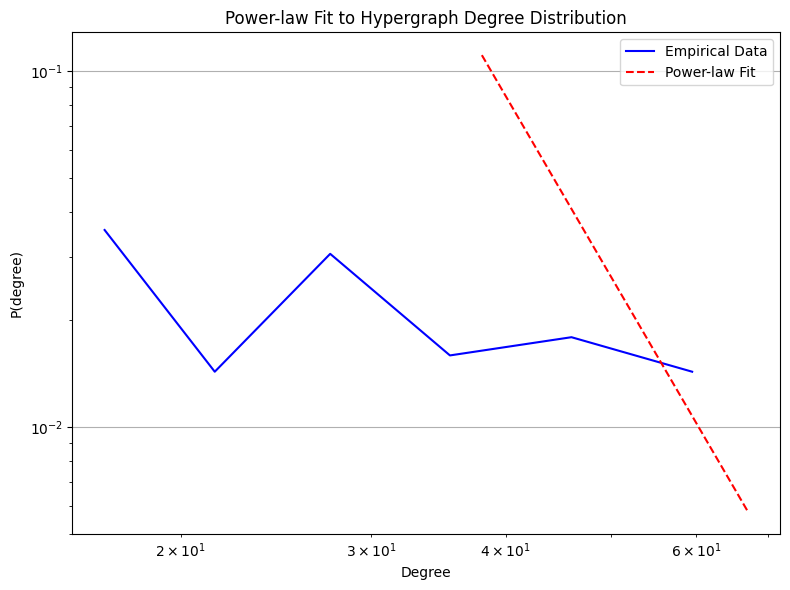

In [130]:
# Normal
print(H)
degree_dict = H.degree()
print(degree_dict)
degree_list = list(degree_dict.values())
#print(degree_list)
sorted_degrees = sorted(degree_dict.values())
print(sorted_degrees)
truncated_degrees = [d for d in degree_list if d >= 1]
print(truncated_degrees)

fit = powerlaw.Fit(sorted_degrees, xmin=0)
# print(fit.fixed_xmin)
print(f"Power-law alpha: {fit.power_law.alpha:.4f}")
print(f"xmin: {fit.xmin}")
print(f"Sigma: {fit.power_law.sigma:.4f}")

R, p = fit.distribution_compare('power_law', 'exponential')
print(f"Loglikelihood ratio R: {R:.4f}")
print(f"p-value: {p:.4f}")

plt.figure(figsize=(8, 6))
powerlaw.plot_pdf(truncated_degrees, color='b', label='Empirical Data')
fit.power_law.plot_pdf(color='r', linestyle='--', label='Power-law Fit')
plt.xlabel("Degree")
plt.ylabel("P(degree)")
plt.title("Power-law Fit to Hypergraph Degree Distribution")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Unnamed Hypergraph with 50 nodes and 413 hyperedges
{0: 13, 1: 25, 2: 23, 3: 22, 4: 10, 5: 35, 6: 15, 7: 25, 8: 14, 9: 12, 10: 35, 11: 19, 12: 20, 13: 27, 14: 26, 15: 10, 16: 26, 17: 19, 18: 29, 19: 23, 20: 25, 21: 8, 22: 33, 23: 31, 24: 16, 25: 3, 26: 24, 27: 25, 28: 21, 29: 41, 30: 36, 31: 27, 32: 13, 33: 26, 34: 32, 35: 35, 36: 37, 37: 11, 38: 20, 39: 34, 40: 8, 41: 22, 42: 16, 43: 21, 44: 28, 45: 20, 46: 19, 47: 13, 48: 16, 49: 24}
[13, 25, 23, 22, 10, 35, 15, 25, 14, 12, 35, 19, 20, 27, 26, 10, 26, 19, 29, 23, 25, 8, 33, 31, 16, 3, 24, 25, 21, 41, 36, 27, 13, 26, 32, 35, 37, 11, 20, 34, 8, 22, 16, 21, 28, 20, 19, 13, 16, 24]
[3, 8, 8, 10, 10, 11, 12, 13, 13, 13, 14, 15, 16, 16, 16, 19, 19, 19, 20, 20, 20, 21, 21, 22, 22, 23, 23, 24, 24, 25, 25, 25, 25, 26, 26, 26, 27, 27, 28, 29, 31, 32, 33, 34, 35, 35, 35, 36, 37, 41]
truncated_degrees: [35, 35, 41, 36, 35, 37]
Power-law alpha: 25.7970
xmin: 35.0
Sigma: 10.1233
Loglikelihood ratio R: 0.1231
p-value: 0.2307


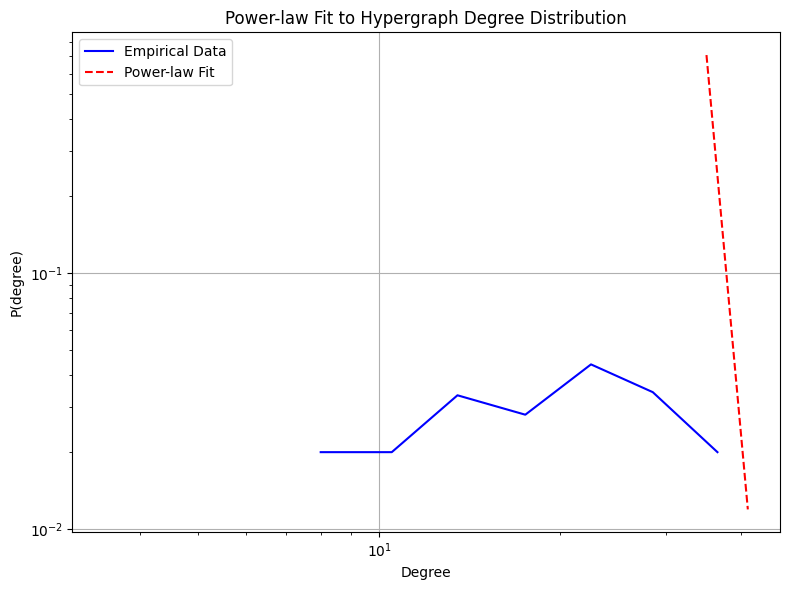

In [204]:
#Turncate
print(H)
degree_dict = H.degree()
print(degree_dict)
degree_list = list(degree_dict.values())
print(degree_list)
sorted_degrees = sorted(degree_dict.values())
print(sorted_degrees)
# Truncate the degree list
truncated_degrees = [d for d in degree_list if d >= 35]
print(f"truncated_degrees: {truncated_degrees}")

fit2 = powerlaw.Fit(truncated_degrees, xmin=35)
# print(fit.fixed_xmin)
print(f"Power-law alpha: {fit2.power_law.alpha:.4f}")
print(f"xmin: {fit2.xmin}")
print(f"Sigma: {fit2.power_law.sigma:.4f}")

R, p = fit2.distribution_compare('power_law', 'exponential')
print(f"Loglikelihood ratio R: {R:.4f}")
print(f"p-value: {p:.4f}")

plt.figure(figsize=(8, 6))
powerlaw.plot_pdf(degree_list, color='b', label='Empirical Data')
fit2.power_law.plot_pdf(color='r', linestyle='--', label='Power-law Fit')
plt.xlabel("Degree")
plt.ylabel("P(degree)")
plt.title("Power-law Fit to Hypergraph Degree Distribution")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Hypergraph named Diseasome with 516 nodes and 903 hyperedges
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,

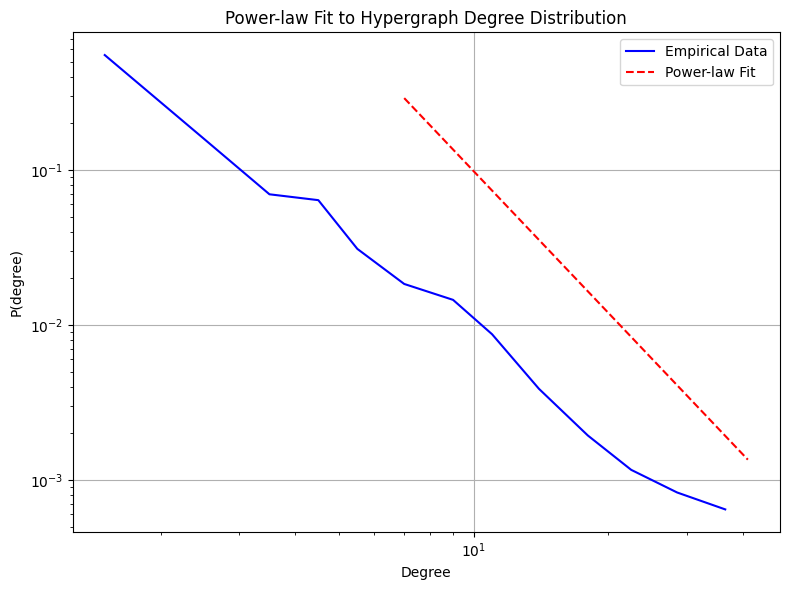

In [16]:
from edge_rewiring import edge_rewiring_alg

H = xgi.load_xgi_data(edge_rewiring_exper.datasets[6])
# es = edit_simpliciality(H, min_size=2)
# print(f"Edit simpliciality: {es}")

print(H)
degree_dict = H.degree()
#print(degree_dict)
degree_list = list(degree_dict.values())
#print(degree_list)
sorted_degrees = sorted(degree_dict.values())
filtered_degrees = [d for d in sorted_degrees if d > 0]
print(filtered_degrees)

fit = powerlaw.Fit(filtered_degrees)
print(f"Power-law alpha: {fit.power_law.alpha:.4f}")
print(f"xmin: {fit.xmin}")
print(f"Sigma: {fit.power_law.sigma:.4f}")

R, p = fit.distribution_compare('power_law', 'exponential')
print(f"Loglikelihood ratio R: {R:.4f}")
print(f"p-value: {p:.4f}")

plt.figure(figsize=(8, 6))
powerlaw.plot_pdf(filtered_degrees, color='b', label='Empirical Data')
fit.power_law.plot_pdf(color='r', linestyle='--', label='Power-law Fit')
plt.xlabel("Degree")
plt.ylabel("P(degree)")
plt.title("Power-law Fit to Hypergraph Degree Distribution")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [80]:
import math

sum = 0

for i in range(2, 3 + 1):
    sum += math.comb(3, i)
    print(f"i: {i}")
    print(sum)

nodes = [i for i in range(3)]
print(nodes)

i: 2
3
i: 3
4
[0, 1, 2]
